In [1]:
import numpy as np
import ants
import matplotlib.pyplot as plt
import os
import gc
import nibabel as nib
from mpl_toolkits.axes_grid1 import ImageGrid
import logger
import pandas as pd

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import LabelEncoder
from sklearn.utils import shuffle

import tensorflow as tf
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.utils import to_categorical
from antspynet import brain_extraction


import matplotlib.pyplot as plt
import gc
import seaborn as sns

from reportlab.lib.pagesizes import letter
from reportlab.pdfgen import canvas
from PIL import Image
import tempfile

2025-10-13 21:06:14.345137: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-10-13 21:06:14.382937: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-13 21:06:14.599552: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:32] Could not find cuda drivers on your machine, GPU will not be used.
2025-10-13 21:06:14.801844: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-10-13 21:06:14.939582: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been 

In [2]:
def winsorize_image(image_data, lower_percentile=0, upper_percentile=99.9): #reduz valores extremos
    lower_bound = np.percentile(image_data, lower_percentile)
    upper_bound = np.percentile(image_data, upper_percentile)
    winsorized_data = np.clip(image_data, lower_bound, upper_bound)
    return winsorized_data

def normalize_image_min(image_data): #normalizar 
    min_val = np.min(image_data)
    max_val = np.max(image_data)
    normalized_data = (image_data - min_val) / (max_val - min_val)
    return normalized_data

# Função para processar uma única imagem
def process_image(img_path, template, registro='Affine', orientation='false'):
    try:
        logger.info(f"Inicio processamento: {img_path}")
        # Carrega a imagem
        image = ants.image_read(img_path,reorient=orientation)

        # Registra pra padronizar shape da imagem
        registration = ants.registration(fixed=template, moving=image, type_of_transform=registro)
        affine_image = registration['warpedmovout']
        brain_masked = affine_image

        # Cria template pra máscara
        prob_mask = brain_extraction(affine_image, modality='t1')
        # logger.info(f"Template obtido.")

        # # Cria a máscara
        mask = ants.get_mask(prob_mask, low_thresh=0.5)
        # logger.info(f"Máscara aplicada.")

        # # Máscara do cérebro e extração
        brain_masked = ants.mask_image(affine_image, mask)
        # logger.info(f"Extração.")

        # Bias Field Correction
        #image = ants.from_numpy(data, origin=image.origin, spacing=image.spacing, direction=image.direction)
        image = ants.n4_bias_field_correction(brain_masked, shrink_factor=2)
        data = image.numpy()
        logger.info(f"Bias Corrigido.")

        # Winsorizing
        data = winsorize_image(data, 0, 99.9)
        logger.info(f"Winsorized.")

        # Normalização
        data = normalize_image_min(data)
        image = ants.from_numpy(data, origin=brain_masked.origin, spacing=brain_masked.spacing, direction=brain_masked.direction)

        logger.info(f"Imagem {img_path} processada.")

        #ants.image_write(image, output_path)
        #logger.info(f"Imagem salva: {os.path.basename(output_path)}")

        gc.collect()

        return image
        
    except Exception as e:
        logger.error(f"Erro ao processar a imagem {img_path}: {e}")
        return None
    
def plot_views(image, k=0):
    fig, axs = plt.subplots(1, 3)
    size = image.shape

    axs[0].imshow(np.rot90(image[size[0]//2, :, :], k=k), cmap='grey')
    axs[0].set_title("esperado: sagital")
    axs[0].axis('off')
    
    axs[1].imshow(np.rot90(image[:, size[1]//2, :]), cmap='grey')
    axs[1].set_title("esperado: coronal")
    axs[1].axis('off')

    axs[2].imshow(np.rot90(image[:, :, size[2]//2], k=k), cmap='grey')
    axs[2].set_title("esperado: axial")
    axs[2].axis('off')
    
    fig.tight_layout(rect=[0, 0, 1, 0.8])
    plt.show()

def plot_one_view(image, index=80, rot=0, title=''):
    image = np.rot90(image[:, :, index], k=rot)
    plt.figure(figsize=(10,6))
    plt.imshow(image, cmap='gray')
    plt.title(title)
    plt.axis('off')
    plt.show()

def unificar_tamanhos_com_padding(lista_de_imagens):
    max_altura = 0
    max_largura = 0
    for img in lista_de_imagens:
        altura, largura = img.shape
        if altura > max_altura:
            max_altura = altura
        if largura > max_largura:
            max_largura = largura

    imagens_uniformes = []
    for img in lista_de_imagens:
        fundo = np.zeros((max_altura, max_largura))
        
        altura_img, largura_img = img.shape
        y_offset = (max_altura - altura_img) // 2
        x_offset = (max_largura - largura_img) // 2
        
        fundo[y_offset:y_offset+altura_img, x_offset:x_offset+largura_img] = img
        imagens_uniformes.append(fundo)
        
    return imagens_uniformes

def plot_views_uniforme_final(image, k=0, sag_idx=90, cor_idx=110, ax_idx=110, figsize=(15, 5), axes_pad=0.3):
    fig = plt.figure(figsize=figsize)
    grid = ImageGrid(fig, 111,
                    nrows_ncols=(1, 3),
                    axes_pad=axes_pad)
    
    slices_originais = [
        np.rot90(image[sag_idx, :, :], k=k),
        np.rot90(image[:, cor_idx, :], k=k),
        np.rot90(image[:, :, ax_idx], k=k)
    ]
    
    slices_uniformizadas = unificar_tamanhos_com_padding(slices_originais)
    
    titles = ["Sagital", "Coronal", "Axial"]

    for ax, im_slice, title in zip(grid, slices_uniformizadas, titles):
        ax.imshow(im_slice, cmap='gray')
        ax.set_title(title)
        ax.axis('off')

    plt.show()

# realizar predições e armazenar em um vetor
def get_predictions(images, labels, batch_size, best_model):
    pred = []

    for i in range(0, len(images), batch_size):
        final = min(i + batch_size, len(images))
        
        # Fazendo predição para o lote atual
        batch_pred = best_model.predict(images[i:final])
        pred.append(batch_pred)

    # Concatenando as predições e os rótulos verdadeiros
    pred = np.concatenate(pred)

    # Convertendo as predições para rótulos (a classe com maior probabilidade)
    true_labels = np.argmax(labels, axis=1)
    pred_labels = np.argmax(pred, axis=1)
    return pred_labels, true_labels, pred

def plot_confusion_matrix(y_true, y_pred, dir, subset, class_names):
    # Calcular a matriz de confusão
    cm = confusion_matrix(y_true, y_pred)

    # Plotando a matriz de confusão
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names,  annot_kws={"size": 14})
    plt.xlabel('Previsões')
    plt.ylabel('Valores Reais')
    plt.title('Matriz de Confusão')
    plt.savefig(f'{dir}/{subset}_confusion_matrix.png')
    plt.show()

def plot_custom_confusion_matrix(cm, y_labels, x_labels, dir, subset):
    plt.figure(figsize=(10, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
                xticklabels=x_labels, yticklabels=y_labels, 
                annot_kws={"size": 14})
    plt.xlabel('Previsões')
    plt.ylabel('Valores Reais')
    plt.title('Matriz de Confusão Ajustada')
    plt.savefig(f'{dir}/{subset}_custom_confusion_matrix.png', bbox_inches='tight')
    plt.show()

def get_classification_report(y_true, y_pred, dir, subset):
    # Gerar relatório
    report = classification_report(y_true, y_pred)
    print(report)

    # Escrevendo o relatório em um arquivo .txt
    with open(os.path.join(dir, f"{subset}_classification_report.txt"), "w") as file:
        file.write(report)

def load_nifti_data_balanced(base_dir, class_names, target=1000):
    images = []
    labels = []
    paths = []
    
    # Caminhos das subpastas
    for label in class_names:
        print(f"carregando diretório {label}")
        label_dir = os.path.join(base_dir, label)
        count = 0

        names = os.listdir(label_dir)
        #np.random.shuffle(names)
        for fname in names:
            #if count < target:
            img_path = os.path.join(label_dir, fname)
            img = nib.load(img_path).get_fdata(dtype=np.float16)
            paths.append(img_path)
            images.append(img)
            labels.append(label)
            count += 1

        print(f"diretório carregado {count}")

    # Codificando os rótulos
    label_encoder = LabelEncoder()
    label_encoder.classes_ = np.array(class_names)
    labels_encoded = label_encoder.transform(labels)
    labels_one_hot = to_categorical(labels_encoded, num_classes=len(class_names))

    # Convertendo para arrays NumPy
    images = np.array(images).reshape((-1, *images[0].shape, 1))
    labels_one_hot = np.array(labels_one_hot)
    
    # Embaralhar os dados
    images, labels_one_hot, paths = shuffle(images, labels_one_hot, paths, random_state=42)
    
    return images, labels_one_hot, paths, label_encoder.classes_


# Função para criar o PDF
def create_pdf(y_paths, y_images, y_true_labels, y_pred_labels, y_pred, output_pdf_path, class_names):
    c = canvas.Canvas(output_pdf_path, pagesize=letter)
    width, height = letter  # Dimensões da página no PDF

    #for image, name in zip(y_images, y_paths):
    for i in range(0, len(y_images)):
        true = ''
        pred = ''
        # Carregar a imagem NIfTI e obter a fatia 2D no eixo Z
        # nifti_image = load_nifti_image_pdf(item)
        nifti_image = y_images[i][:, :, 88, 0]

        # Converter a fatia 2D para uma imagem 8-bit (grayscale) para visualização
        img = Image.fromarray(np.uint8(nifti_image / np.max(nifti_image) * 255))  # Normalizar e converter
        img = img.convert("RGB")  # Garantir que a imagem tenha 3 canais (RGB)

        # Redimensionar a imagem para se ajustar ao tamanho da página
        img_width, img_height = img.size
        aspect_ratio = img_height / float(img_width)
        new_width = width * 0.2  # Definir largura como 80% da largura da página
        new_height = new_width * aspect_ratio
        img = img.resize((int(new_width), int(new_height)))

        # Criar um arquivo temporário para salvar a imagem
        with tempfile.NamedTemporaryFile(delete=False, suffix=".png") as temp_file:
            temp_file_path = temp_file.name
            img.save(temp_file_path)

        # configurar para printar as 7 fatias em uma página inteira, com as informações de label predito e esperado

        # Colocar a imagem no PDF usando o caminho temporário
        if i % 12 < 4:
            x = 80
        elif i % 12 < 8:
            x = width - 2.35*new_width - 80
        else:
            x = width - new_width - 80

        y = height - (new_height + 80)*((i%4)+1)

        c.drawImage(temp_file_path, x, y, width=new_width, height=new_height)

        # Escrever os rótulos
        true_label = y_true_labels[i]
        pred_label = y_pred_labels[i]

        #ver como transformar os labels de maneira inteligente
        true = class_names[true_label]
        pred = class_names[pred_label]

        # Definir a cor para os rótulos
        if true_label == pred_label:
            pred_color = (0, 1, 0)  # Verde
        else:
            pred_color = (1, 0, 0)  # Vermelho
        
        #Nome paciente (em preto)
        c.setFont("Helvetica", 12)
        c.setFillColorRGB(0, 0, 0)  # Preto
        c.drawString(x+24, y+new_height+50, f"{os.path.basename(y_paths[i])}")

        # Rótulo esperado (em preto)
        c.setFont("Helvetica", 12)
        c.setFillColorRGB(0, 0, 0)  # Preto
        c.drawString(x+26, y+new_height+35, f"Expected: {true}")

        # Rótulo predito
        c.setFont("Helvetica", 12)
        c.setFillColorRGB(*pred_color)  # Verde ou Vermelho
        c.drawString(x+26, y+new_height+20, f"Predicted: {pred}")

        # Rótulo predito
        c.setFont("Helvetica", 12)
        c.setFillColorRGB(*pred_color)  # Verde ou Vermelho
        c.drawString(x+26, y+new_height+5, f"Prob: {max(y_pred[i])*100:.2f}%")

        # Avançar para a próxima imagem
        i += 1
        
        # Adicionar uma nova página no PDF a cada 2 imagens (se necessário)
        if i % 12 == 0:  # Por exemplo, a cada 2 imagens, adicionamos uma nova página
            c.showPage()

    # Salvar o PDF
    c.save()

In [3]:
oasis_dir = f"/mnt/c/Users/Bruno/Desktop/IANS/OAS2_RAW_PART2"
output_dir = f"/mnt/c/Users/Bruno/Desktop/IANS/OASIS_2_RAW"
os.makedirs(output_dir, exist_ok=True)

oasis_data_path = "/mnt/c/Users/Bruno/Desktop/IANS/oasis_2_data.xlsx"
oasis_data = pd.read_excel(oasis_data_path)

template_path = f"{dir}/Alzheimer-CNN-Detection/pre_processing/mni_icbm152_nlin_asym_09c_nifti/mni_icbm152_nlin_asym_09c/mni_icbm152_t1_tal_nlin_asym_09c.nii"
# template = ants.image_read(template_path)
mask_path = f"{dir}/Alzheimer-CNN-Detection/pre_processing/mni_icbm152_nlin_asym_09c_nifti/mni_icbm152_nlin_asym_09c/mni_icbm152_t1_tal_nlin_asym_09c_mask.nii"
# mask = ants.image_read(mask_path)

In [12]:
groups = oasis_data[['Subject ID', 'CDR']]
groups = groups.set_index('Subject ID', drop=False)
print(groups)

           Subject ID  CDR
Subject ID                
OAS2_0001   OAS2_0001  0.0
OAS2_0001   OAS2_0001  0.0
OAS2_0002   OAS2_0002  0.5
OAS2_0002   OAS2_0002  0.5
OAS2_0002   OAS2_0002  0.5
...               ...  ...
OAS2_0185   OAS2_0185  0.5
OAS2_0185   OAS2_0185  0.5
OAS2_0186   OAS2_0186  0.0
OAS2_0186   OAS2_0186  0.0
OAS2_0186   OAS2_0186  0.0

[373 rows x 2 columns]


In [13]:
subjects = os.listdir(oasis_dir)

print(subjects)

for sub in subjects:
    if sub.endswith("MR1"):
        group = groups.loc[sub.split('_MR')[0], 'CDR'].iloc[0]
        sub_path = f"{oasis_dir}/{sub}/RAW/mpr-1.nifti.img"
        print(sub)
        img = ants.image_read(sub_path)
        sub_output_dir = f"{output_dir}/{group}"
        os.makedirs(sub_output_dir, exist_ok=True)
        ants.image_write(img, f"{sub_output_dir}/{sub}.nii.gz")

['OAS2_0100_MR1', 'OAS2_0100_MR2', 'OAS2_0100_MR3', 'OAS2_0101_MR1', 'OAS2_0101_MR2', 'OAS2_0101_MR3', 'OAS2_0102_MR1', 'OAS2_0102_MR2', 'OAS2_0102_MR3', 'OAS2_0103_MR1', 'OAS2_0103_MR2', 'OAS2_0103_MR3', 'OAS2_0104_MR1', 'OAS2_0104_MR2', 'OAS2_0105_MR1', 'OAS2_0105_MR2', 'OAS2_0106_MR1', 'OAS2_0106_MR2', 'OAS2_0108_MR1', 'OAS2_0108_MR2', 'OAS2_0109_MR1', 'OAS2_0109_MR2', 'OAS2_0111_MR1', 'OAS2_0111_MR2', 'OAS2_0112_MR1', 'OAS2_0112_MR2', 'OAS2_0113_MR1', 'OAS2_0113_MR2', 'OAS2_0114_MR1', 'OAS2_0114_MR2', 'OAS2_0116_MR1', 'OAS2_0116_MR2', 'OAS2_0117_MR1', 'OAS2_0117_MR2', 'OAS2_0117_MR3', 'OAS2_0117_MR4', 'OAS2_0118_MR1', 'OAS2_0118_MR2', 'OAS2_0119_MR1', 'OAS2_0119_MR2', 'OAS2_0119_MR3', 'OAS2_0120_MR1', 'OAS2_0120_MR2', 'OAS2_0121_MR1', 'OAS2_0121_MR2', 'OAS2_0122_MR1', 'OAS2_0122_MR2', 'OAS2_0124_MR1', 'OAS2_0124_MR2', 'OAS2_0126_MR1', 'OAS2_0126_MR2', 'OAS2_0126_MR3', 'OAS2_0127_MR1', 'OAS2_0127_MR2', 'OAS2_0127_MR3', 'OAS2_0127_MR4', 'OAS2_0127_MR5', 'OAS2_0128_MR1', 'OAS2_0128_MR

(160, 189, 157)


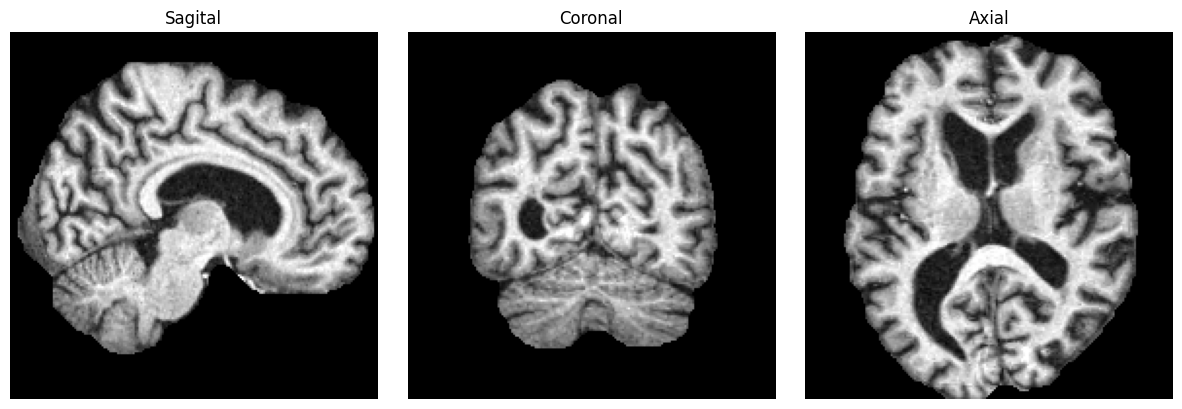

In [6]:
img = ants.image_read(f"{test_dir}/0.0/{os.listdir(f"{test_dir}/0.0")[0]}")

SLICE_NII_IDX0 = slice(15, 175)
SLICE_NII_IDX1 = slice(21, 210)
SLICE_NII_IDX2 = slice(7, 164)

data = img.numpy()[SLICE_NII_IDX0, SLICE_NII_IDX1, SLICE_NII_IDX2]
print(data.shape)
plot_views_uniforme_final(data, 1, 90, 40, 82)

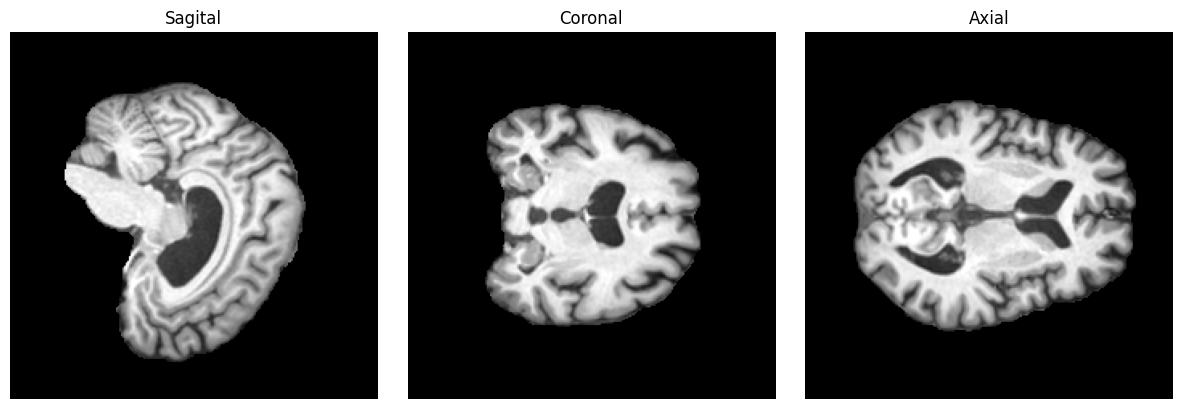

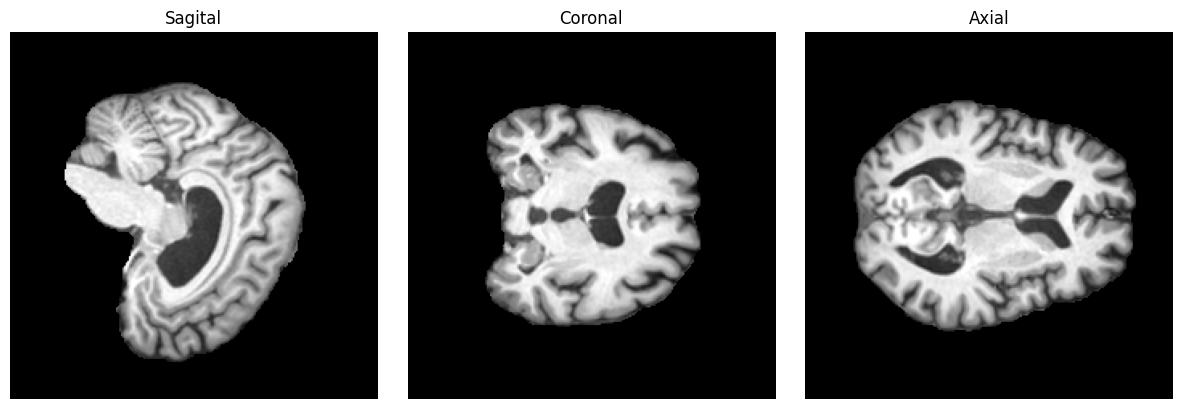

In [86]:
# PLOTS ADNI
adni_proc_path = f"/mnt/c/Users/Bruno/Desktop/IANS/Alzheimer/test_affine/cn"

adni_img_proc = ants.image_read(f"{adni_proc_path}/{os.listdir(adni_proc_path)[6]}")

adni_wins = winsorize_image(adni_img_proc.numpy(), 0, 99.9)

plot_views_uniforme_final(adni_wins, 0, 90, 120, 85)
plot_views_uniforme_final(adni_img_proc.numpy(), 0, 90, 120, 85)

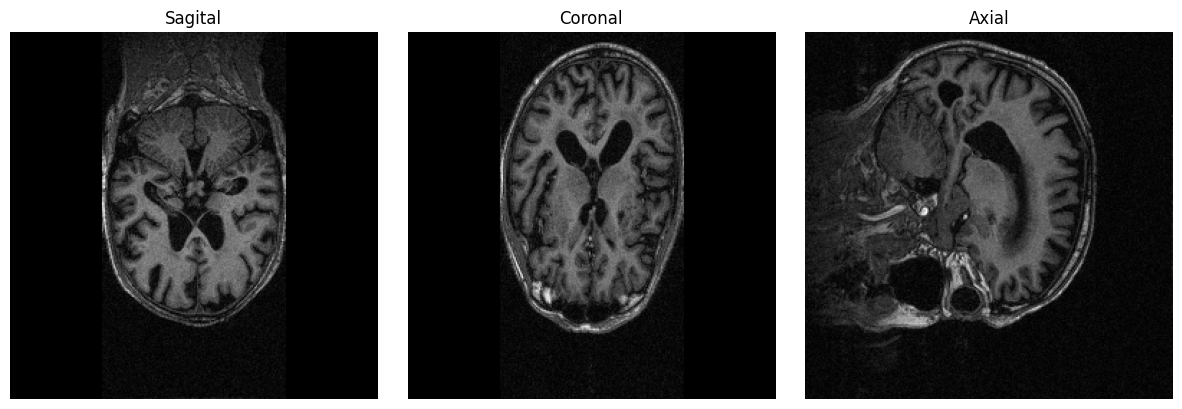

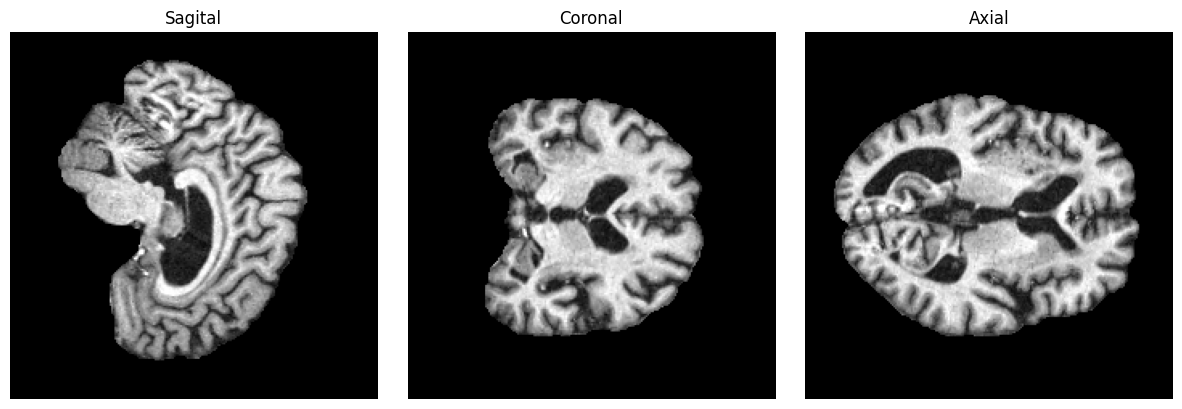

In [57]:
# PLOTS OASIS
raw_path = f"{output_dir}/0.0"
proc_path = f"{test_dir}/0.0"

oasis_img_raw = ants.image_read(f"{raw_path}/{os.listdir(raw_path)[0]}")
oasis_img_proc = ants.image_read(f"{proc_path}/{os.listdir(proc_path)[0]}")

plot_views_uniforme_final(oasis_img_raw.numpy(), 0, 90, 130, 82)

plot_views_uniforme_final(oasis_img_proc.numpy(), 0, 90, 120, 82)

In [16]:
adni_classes = ['CN', 'EMCI', 'MCI', 'LMCI', 'AD']
oasis_classes = ['0.0', '0.5', '1.0']
class_names = oasis_classes

model = load_model(f"/mnt/c/Users/Bruno/Desktop/IANS/OASIS_2_PROCESSED/binary_classifier_150_epochs_batch_64_5_classes.keras")

model.summary()

test_dir = f"/mnt/c/Users/Bruno/Desktop/IANS/OASIS_2_PROCESSED"
results_dir = f"{test_dir}/results"
os.makedirs(results_dir, exist_ok=True)

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 160, 189, 157,  │             0 │
│                                 │ 1)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ cast_2 (Cast)                   │ (None, 160, 189, 157,  │             0 │
│                                 │ 1)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d (Conv3D)                 │ (None, 160, 189, 157,  │           112 │
│                                 │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 160, 189, 157,  │            16 │
│ (BatchNormalization)            │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu (LeakyReLU)         │ (None, 160, 189, 157,  │             0 │
│                                 │ 4)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d               │ (None, 54, 63, 53, 4)  │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 54, 63, 53, 4)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_1 (Conv3D)               │ (None, 54, 63, 53, 8)  │           872 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 54, 63, 53, 8)  │            32 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_1 (LeakyReLU)       │ (None, 54, 63, 53, 8)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d_1             │ (None, 18, 21, 18, 8)  │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 18, 21, 18, 8)  │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_2 (Conv3D)               │ (None, 18, 21, 18, 16) │         3,472 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 18, 21, 18, 16) │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ leaky_re_lu_2 (LeakyReLU)       │ (None, 18, 21, 18, 16) │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ average_pooling3d_2             │ (None, 6, 7, 6, 16)    │             0 │
│ (AveragePooling3D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 6, 7, 6, 16)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv3d_3 (Conv3D)               │ (None, 6, 7, 6, 32)    │        13,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 6, 7, 6, 32)    │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 831,881 (3.17 MB)

 Trainable params: 277,221 (1.06 MB)

 Non-trainable params: 216 (864.00 B)

 Optimizer params: 554,444 (2.12 MB)

In [7]:
test_images, test_labels, test_paths, _ = load_nifti_data_balanced(test_dir, class_names)

carregando diretório 0.0
diretório carregado 85
carregando diretório 0.5
diretório carregado 52
carregando diretório 1.0
diretório carregado 13


In [8]:
test_images_crop = []

for i in range(len(test_images)):
    backup = test_images[i]
    # print(backup.shape)
    test_images_crop.append(backup[SLICE_NII_IDX0, SLICE_NII_IDX1, SLICE_NII_IDX2])

test_images_crop = np.array(test_images_crop)

print(test_images_crop.shape)

(150, 160, 189, 157, 1)


In [9]:
# Realizar predições para dados do conjunto validação
test_pred_labels, test_true_labels, test_pred = get_predictions(test_images_crop, test_labels, 8, model)

2025-10-13 21:12:16.268854: E tensorflow/core/util/util.cc:131] oneDNN supports DT_HALF only on platforms with AVX-512. Falling back to the default Eigen-based implementation if present.
I0000 00:00:1760400736.278274    2153 service.cc:146] XLA service 0x7c33b400d970 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1760400736.279119    2153 service.cc:154]   StreamExecutor device (0): Host, Default Version
2025-10-13 21:12:16.350061: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2025-10-13 21:12:17.783903: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 1s:

  %reduce-window.153 = f32[8,40,48,40,4]{4,3,2,1,0} reduce-window(f32[8,80,95,79,4]{4,3,2,1,0} %broadcast.141, f32[] %constant.142), window={size=1x2x2x2x1 stride=1x2x2x2x1 pad=0_0x0_0x0_1x0_1x0_0}, to_apply=%region_

1/1 ━━━━━━━━━━━━━━━━━━━━ 9s 9s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


2025-10-13 21:13:20.523899: E external/local_xla/xla/service/slow_operation_alarm.cc:65] Constant folding an instruction is taking > 2s:

  %reduce-window.153 = f32[6,40,48,40,4]{4,3,2,1,0} reduce-window(f32[6,80,95,79,4]{4,3,2,1,0} %broadcast.141, f32[] %constant.142), window={size=1x2x2x2x1 stride=1x2x2x2x1 pad=0_0x0_0x0_1x0_1x0_0}, to_apply=%region_1.149, metadata={op_type="AvgPool3D" op_name="functional_1/average_pooling3d_1_2/AvgPool3D"}

This isn't necessarily a bug; constant-folding is inherently a trade-off between compilation time and speed at runtime. XLA has some guards that attempt to keep constant folding from taking too long, but fundamentally you'll always be able to come up with an input program that takes a long time.

If you'd like to file a bug, run with envvar XLA_FLAGS=--xla_dump_to=/tmp/foo and attach the results.
2025-10-13 21:13:21.330049: E external/local_xla/xla/service/slow_operation_alarm.cc:133] The operation took 2.808985217s
Constant folding an instructio

1/1 ━━━━━━━━━━━━━━━━━━━━ 6s 6s/step


In [21]:
n = len(os.listdir(results_dir))

# if (n > 0):
#     if (len(os.listdir(os.path.join(results_dir, f'test_{n}'))) < 3): 
#         for item in os.listdir(os.path.join(results_dir, f"test_{n}")):
#             os.remove(os.path.join(results_dir,  f"test_{n}", item))
#         os.removedirs(os.path.join(results_dir, f'test_{n}'))
#         n -= 1

folder_name = f"test_{str(n+1)}"
folder_dir = os.path.join(results_dir, folder_name)
os.makedirs(folder_dir, exist_ok=True)
print(f"pasta {folder_name} criada")

pasta test_2 criada


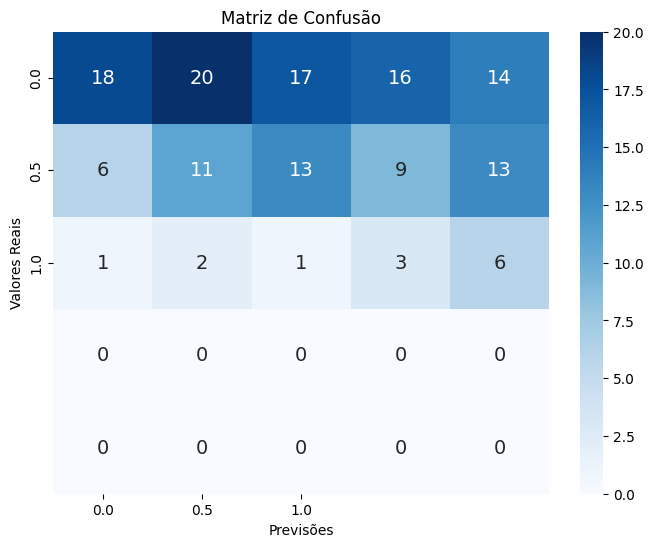

In [22]:
# Obter métricas da valiadação e salvá-las em um arquivo
# get_classification_report(test_true_labels, test_pred_labels, results_dir, 'test')

# Obter matriz de confusão
plot_confusion_matrix(test_true_labels, test_pred_labels, folder_dir, 'test_5x5', class_names)

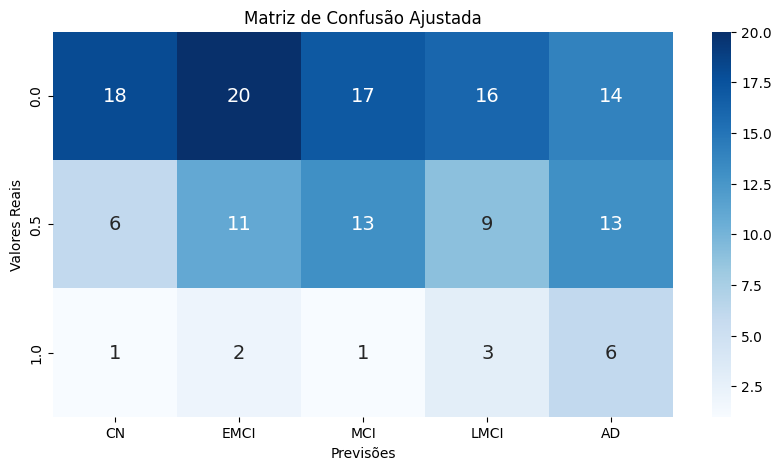

In [23]:
# all_possible_numeric_labels = [0.0, 0.5, 1.0, 2.0, 3.0]

cm_adjusted = confusion_matrix(test_true_labels, test_pred_labels)[0:3, :]

# Chame a nova função para plotar a matriz ajustada (3x5)
plot_custom_confusion_matrix(cm_adjusted, oasis_classes, adni_classes, folder_dir, 'test_3x5')


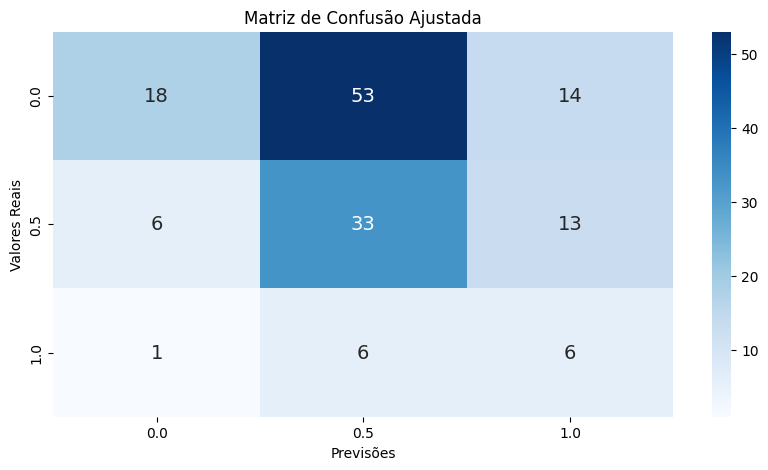

In [24]:
gathered_test_pred = []

for i in range(len(test_pred_labels)):
    if test_pred_labels[i] == 0:
        gathered_test_pred.append(0)
    elif test_pred_labels[i] < 4 and test_pred_labels[i] > 0:
        gathered_test_pred.append(1)
    else:
        gathered_test_pred.append(2)

# all_possible_numeric_labels = [0.0, 0.5, 1.0, 2.0, 3.0]

cm_3x3_adjusted = confusion_matrix(test_true_labels, gathered_test_pred)[0:3, :]

# Chame a nova função para plotar a matriz ajustada (3x5)
plot_custom_confusion_matrix(cm_3x3_adjusted, oasis_classes, oasis_classes, folder_dir, 'test_3x3')


In [13]:
# # Criar pdf com predições
# test_pdf_path = os.path.join(results_dir, "oasis_test_predictions.pdf")
# create_pdf(test_paths, test_images, test_true_labels, test_pred_labels, test_pred, test_pdf_path, class_names)